Membuat generator data training dengan augmentasi...
Membuat generator data validasi (tanpa augmentasi)...
Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.

Kelas-kelas yang ditemukan:
{'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3, 'Blueberry___healthy': 4, 'Cherry_(including_sour)___Powdery_mildew': 5, 'Cherry_(including_sour)___healthy': 6, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7, 'Corn_(maize)___Common_rust_': 8, 'Corn_(maize)___Northern_Leaf_Blight': 9, 'Corn_(maize)___healthy': 10, 'Grape___Black_rot': 11, 'Grape___Esca_(Black_Measles)': 12, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13, 'Grape___healthy': 14, 'Orange___Haunglongbing_(Citrus_greening)': 15, 'Peach___Bacterial_spot': 16, 'Peach___healthy': 17, 'Pepper,_bell___Bacterial_spot': 18, 'Pepper,_bell___healthy': 19, 'Potato___Early_blight': 20, 'Potato___Late_blight': 21, 'Potato___healthy': 22, 'Raspberry___h

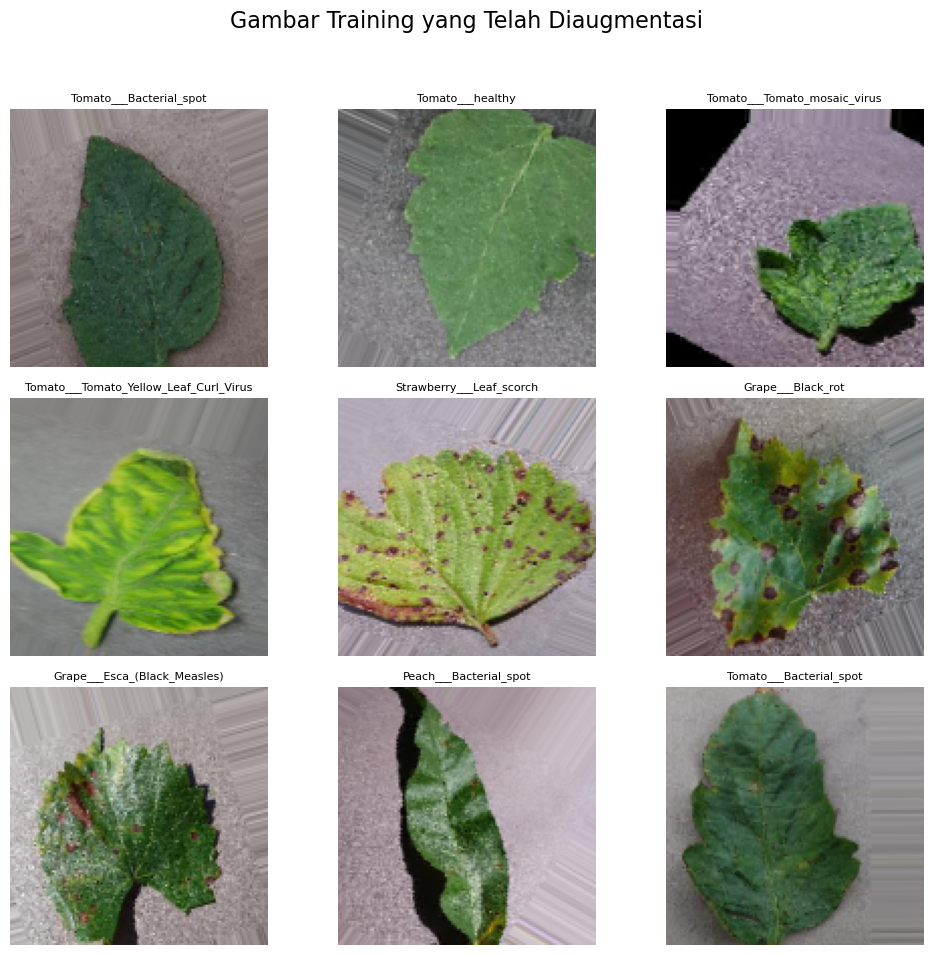

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import os

base_dir = 'C:/Users/ASUS/Documents/PlantLeafDataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)'
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'valid')

IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32 

print("Membuat generator data training dengan augmentasi...")

train_datagen = ImageDataGenerator(
    rescale=1./255,              
    rotation_range=40,             
    width_shift_range=0.2,          
    height_shift_range=0.2,        
    shear_range=0.2,             
    zoom_range=0.2,               
    horizontal_flip=True,          
    fill_mode='nearest'
)

print("Membuat generator data validasi (tanpa augmentasi)...")

validation_datagen = ImageDataGenerator(
    rescale=1./255                 
)


train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'      
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH), 
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

print("\nKelas-kelas yang ditemukan:")
class_indices = train_generator.class_indices
print(class_indices)
print(f"\nBerhasil menemukan {len(class_indices)} kelas.")

images, labels = next(train_generator)

print("\nMenampilkan contoh gambar hasil augmentasi dari batch pertama:")
plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    class_name = [k for k, v in class_indices.items() if v == labels[i].argmax()][0]
    plt.title(class_name, fontsize=8)
    plt.axis("off")

plt.suptitle("Gambar Training yang Telah Diaugmentasi", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input, concatenate
from tensorflow.keras.applications import MobileNetV2, ResNet50, DenseNet121
import matplotlib.pyplot as plt


num_classes = train_generator.num_classes
EPOCHS = 10 
all_histories = {}

In [5]:
def create_and_train_model(base_model_class, model_name):
    """
    Fungsi untuk membuat, compile, dan melatih satu model transfer learning.
    """
    print(f"\n--- Memulai Training untuk: {model_name} ---")
    
    base_model = base_model_class(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
                                  include_top=False,
                                  weights='imagenet')
    base_model.trainable = False
    
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x) 
    x = Dropout(0.2)(x)              
    predictions = Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs=base_model.input, outputs=predictions)
    
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    
    history = model.fit(
        train_generator,
        steps_per_epoch=train_generator.samples // BATCH_SIZE,
        validation_data=validation_generator,
        validation_steps=validation_generator.samples // BATCH_SIZE,
        epochs=EPOCHS,
        verbose=1 
    )
    
    print(f"--- Training {model_name} Selesai ---")
    return history

history_mobilenet = create_and_train_model(MobileNetV2, "MobileNetV2")
all_histories['MobileNetV2'] = history_mobilenet

history_resnet = create_and_train_model(ResNet50, "ResNet50")
all_histories['ResNet50'] = history_resnet

history_densenet = create_and_train_model(DenseNet121, "DenseNet121")
all_histories['DenseNet121'] = history_densenet


--- Memulai Training untuk: MobileNetV2 ---
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/10
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 1236s 562ms/step - accuracy: 0.7997 - loss: 0.6337 - val_accuracy: 0.8538 - val_loss: 0.4526
Epoch 2/10
   1/2196 ━━━━━━━━━━━━━━━━━━━━ 3:06 85ms/step - accuracy: 0.8750 - loss: 0.4000

C:\Users\ASUS\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


2196/2196 ━━━━━━━━━━━━━━━━━━━━ 54s 25ms/step - accuracy: 0.8750 - loss: 0.4000 - val_accuracy: 0.8493 - val_loss: 0.4701
Epoch 3/10
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 497s 226ms/step - accuracy: 0.8637 - loss: 0.4191 - val_accuracy: 0.8752 - val_loss: 0.3838
Epoch 4/10
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 56s 25ms/step - accuracy: 0.8438 - loss: 0.4795 - val_accuracy: 0.8756 - val_loss: 0.3837
Epoch 5/10
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 448s 204ms/step - accuracy: 0.8720 - loss: 0.3896 - val_accuracy: 0.8770 - val_loss: 0.3825
Epoch 6/10
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 57s 26ms/step - accuracy: 0.9062 - loss: 0.2647 - val_accuracy: 0.8764 - val_loss: 0.3841
Epoch 7/10
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 450s 205ms/step - accuracy: 0.8808 - loss: 0.3656 - val_accuracy: 0.8834 - val_loss: 0.3764
Epoch 8/10
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 59s 27ms/step - accuracy: 0.9375 - loss: 0.4365 - val_accuracy: 0.8838 - val_loss: 0.3735
Epoch 9/10
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 453s 206ms/step - accuracy: 0.8868 - lo

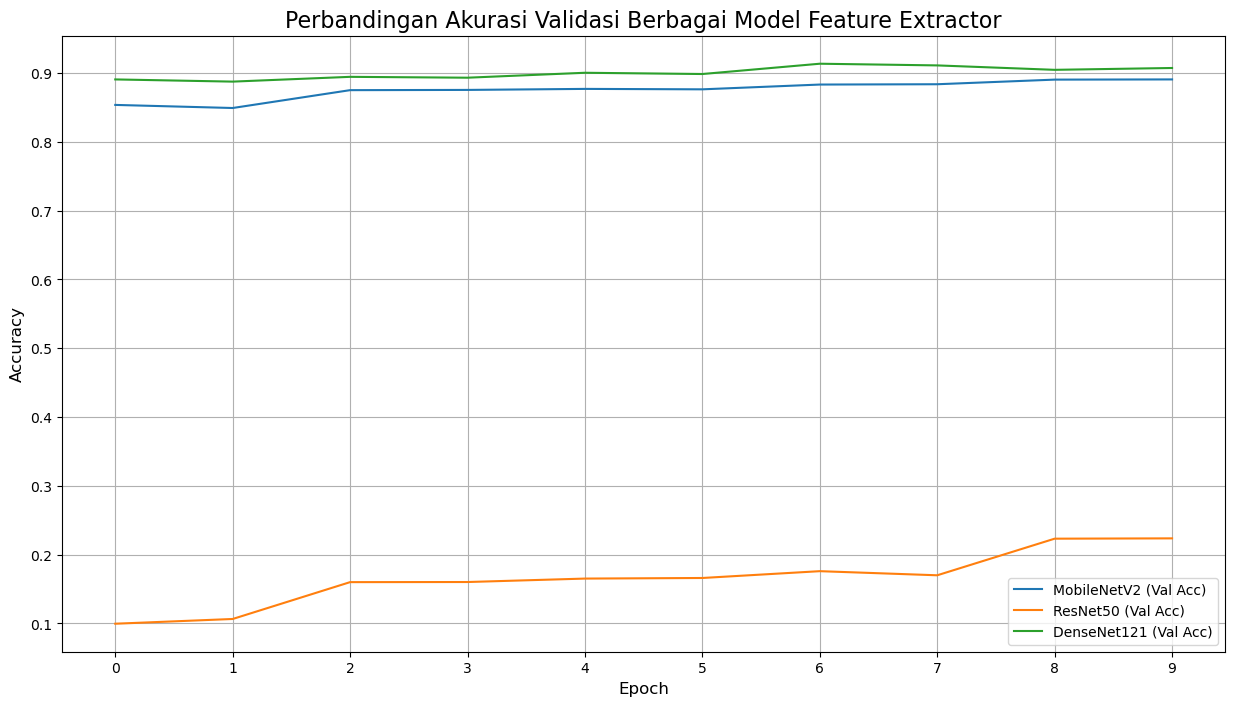

In [11]:
plt.figure(figsize=(15, 8))

for model_name, history in all_histories.items():
    plt.plot(history.history['val_accuracy'], label=f"{model_name} (Val Acc)")

plt.title('Perbandingan Akurasi Validasi Berbagai Model Feature Extractor', fontsize=16)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True)
plt.xticks(range(0, EPOCHS))
plt.show()